In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
%matplotlib inline
from pandas import DataFrame
import numpy as np
import pandas as pd

In [2]:
nsim = 10

In [3]:
ser5_dist = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/ser5_dist/dat/ser5_dist_all.dat', sep = r'\s+')
phos_ser5_dist = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/ser5_dist/dat/ser5_OG_dist_all.dat', sep = r'\s+')

In [4]:
ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)
p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [5]:
ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [6]:
ser5_dist.head()

,#Frame,SER5-SER12,SER12-SER19,SER5-SER19
0,1,12.2447,17.4108,21.1457
1,2,12.7404,17.7596,21.6487
2,3,12.8233,17.7649,21.8352
3,4,12.3779,17.6970,22.0142
4,5,12.7975,17.7532,21.9263


In [7]:
phos_ser5_dist.head()

,#Frame,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,1,22.1742,7.0429,19.6062
1,2,22.4850,7.1859,19.4131
2,3,22.3590,6.7605,19.7073
3,4,22.5715,6.8641,19.7079
4,5,23.0107,7.3316,19.7944


## Frames where phosSer's are closest

In [24]:
phos_ser5_12_close = phos_ser5_dist[phos_ser5_dist['SEP5-SEP12'] < 4.5]
phos_ser12_19_close = phos_ser5_dist[phos_ser5_dist['SEP12-SEP19'] < 4.5]
phos_ser5_19_close = phos_ser5_dist[phos_ser5_dist['SEP5-SEP19'] < 4.5]

In [25]:
phos_ser5_12_close

,#Frame,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19,Frame New
5801279,5801280,4.4705,19.5378,23.9017,1101280
5801324,5801325,4.3617,19.4531,23.7411,1101325
6019072,6019073,4.4219,23.2944,27.2870,1319073
6019130,6019131,4.4467,24.0288,27.6153,1319131
6019149,6019150,4.3955,23.7866,27.4719,1319150
...,...,...,...,...,...
20863329,20863330,4.4331,19.6933,21.8969,1763330
20863331,20863332,4.4992,19.5391,21.4601,1763332
20863332,20863333,4.4121,19.4413,21.1509,1763333
20863333,20863334,4.3805,19.6309,21.3746,1763334


In [23]:
phos_ser5_dist['Frame New'] = (phos_ser5_dist['#Frame'] - 1) % 4800000 + 1 + 100000

In [20]:
phos_ser5_dist.head()

,#Frame,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19,Frame New
0,1,22.1742,7.0429,19.6062,1
1,2,22.4850,7.1859,19.4131,2
2,3,22.3590,6.7605,19.7073,3
3,4,22.5715,6.8641,19.7079,4
4,5,23.0107,7.3316,19.7944,5


In [26]:
ser5_dist.mean()

#Frame         2.400000e+07
SER5-SER12     1.437138e+01
SER12-SER19    1.478634e+01
SER5-SER19     1.891501e+01
dtype: float64

In [27]:
phos_ser5_dist.mean()

#Frame         2.400000e+07
SEP5-SEP12     1.556221e+01
SEP12-SEP19    1.823028e+01
SEP5-SEP19     2.157952e+01
Frame New      2.500000e+06
dtype: float64

In [36]:
noweights

,0
0,2.083333e-08
1,2.083333e-08
2,2.083333e-08
3,2.083333e-08
4,2.083333e-08
...,...
47999995,2.083333e-08
47999996,2.083333e-08
47999997,2.083333e-08
47999998,2.083333e-08


In [35]:
fill_value = 1 / (len(ctd_weights_combined))

noweights = pd.DataFrame(np.full((len(ctd_weights_combined), 1), fill_value))

In [56]:
noweights.sum()

0    1.0
dtype: float64

In [8]:
ser5_dist['weights'] = ctd_weights_combined
phos_ser5_dist['weights'] = p_ctd_weights_combined

In [37]:
# FOR NO WEIGHTS ONLY
ser5_dist['weights'] = noweights
phos_ser5_dist['weights'] = noweights

In [9]:
ser5_dist

,#Frame,SER5-SER12,SER12-SER19,SER5-SER19,weights
0,1,12.2447,17.4108,21.1457,2.068308e-08
1,2,12.7404,17.7596,21.6487,8.310223e-09
2,3,12.8233,17.7649,21.8352,1.665468e-08
3,4,12.3779,17.6970,22.0142,4.747710e-08
4,5,12.7975,17.7532,21.9263,1.088663e-08
...,...,...,...,...,...
47999995,47999996,11.5246,8.7613,10.9497,1.861614e-08
47999996,47999997,11.2591,8.4884,10.5501,1.241771e-08
47999997,47999998,11.1271,8.3000,10.8731,1.139632e-08
47999998,47999999,11.3267,8.2496,11.3749,5.317541e-09


In [60]:
(ser5_dist['SER5-SER12']*ser5_dist['weights']).sum()/ser5_dist['weights'].sum()

14.413644092897618

## Looking at overall average distances

In [10]:
def weighted_mean_and_se(values, weights):
    """
    Calculates the weighted mean and its standard error.

    Args:
        values (array-like): The data values.
        weights (array-like): The corresponding weights for each value.

    Returns:
        tuple: A tuple containing the weighted mean and the standard error of the weighted mean.
    """
    values = np.array(values)
    weights = np.array(weights)

    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    # Create a boolean mask to find non-NaN values in both data and weights.
    valid_mask = ~np.isnan(values) & ~np.isnan(weights)
    
    # Filter the data and weights to keep only valid entries.
    valid_data = values[valid_mask]
    valid_weights = weights[valid_mask]

    # Calculate the weighted mean
    weighted_mean = np.average(valid_data, weights=valid_weights)

    # Calculate the weighted variance
    # For sample variance, adjust for degrees of freedom (n-1)
    # The denominator for weighted variance is typically sum(weights) - (sum(weights^2) / sum(weights))
    # or a simpler form for large samples. Here we use a common form for sample weighted variance.
    sum_of_weights = np.sum(valid_weights)
    weighted_variance = np.sum(valid_weights * (valid_data - weighted_mean)**2) / (sum_of_weights - (np.sum(valid_weights**2) / sum_of_weights))

    # Calculate the standard error of the weighted mean
    # SE = sqrt(weighted_variance / effective_sample_size)
    # Effective sample size can be considered as (sum_of_weights)^2 / sum(weights^2)
    effective_sample_size = (sum_of_weights**2) / np.sum(valid_weights**2)
    standard_error = np.sqrt(weighted_variance / effective_sample_size)

    return weighted_mean, standard_error

In [11]:
ser5_dist_sim_list = np.array_split(ser5_dist, nsim)
phos_ser5_dist_sim_list = np.array_split(phos_ser5_dist, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [13]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
ser5_dist_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [14]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = sim['weights'].sum()

    mean = sim.iloc[:,1:4].mul(sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    ser5_dist_weights.loc[i] = weights
    
    i += 1

In [15]:
sim['weights'].sum()

0.08143269612253326

In [17]:
ser5_dist_weights

,SER5-SER12,SER12-SER19,SER5-SER19
0,0.119147,0.119147,0.119147
1,0.118070,0.118070,0.118070
2,0.118731,0.118731,0.118731
3,0.118723,0.118723,0.118723
4,0.118852,0.118852,0.118852
5,0.081400,0.081400,0.081400
6,0.081282,0.081282,0.081282
7,0.081110,0.081110,0.081110
8,0.081253,0.081253,0.081253
9,0.081433,0.081433,0.081433


In [66]:
# # Calculate the SEM (standard error of the mean)
# mean_values = ser5_dist_all.mean()
# sem_values = ser5_dist_all.sem()

# # Append as a new row labeled 'sem'
# df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
# ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [18]:
mean_list = []
sem_list = []
for i in range(3):
    print(i)
    mean_list.append(weighted_mean_and_se(ser5_dist_all.iloc[:,i].tolist(), ser5_dist_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(ser5_dist_all.iloc[:,i].tolist(), ser5_dist_weights.iloc[:,i].tolist())[1])

0
1
2


In [19]:
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [20]:
ser_dist_overall = ser5_dist_all_final.copy()

In [21]:
ser_dist_overall

,SER5-SER12,SER12-SER19,SER5-SER19
0,14.757841,14.837385,20.407753
1,15.040353,14.788919,19.552076
2,13.829828,14.789913,18.408299
3,15.013569,14.376640,18.493701
4,14.183510,14.822282,19.019777
5,14.221458,14.789346,18.536205
6,14.764283,14.918882,18.325934
7,13.449987,14.650626,17.941508
8,13.986599,14.778764,18.322057
9,14.541884,15.376302,20.360391


In [22]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
phos_ser5_dist_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [23]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = sim['weights'].sum()

    mean = sim.iloc[:,1:4].mul(sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    phos_ser5_dist_weights.loc[i] = weights
    
    i += 1

In [24]:
phos_ser5_dist_weights

,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,1.997744e-01,1.997744e-01,1.997744e-01
1,1.997902e-01,1.997902e-01,1.997902e-01
2,2.002633e-01,2.002633e-01,2.002633e-01
3,1.999205e-01,1.999205e-01,1.999205e-01
4,1.996144e-01,1.996144e-01,1.996144e-01
5,3.302276e-25,3.302276e-25,3.302276e-25
6,6.371756e-04,6.371756e-04,6.371756e-04
7,3.302276e-25,3.302276e-25,3.302276e-25
8,3.302276e-25,3.302276e-25,3.302276e-25
9,3.302276e-25,3.302276e-25,3.302276e-25


In [71]:
# # Calculate the SEM (standard error of the mean)
# mean_values = phos_ser5_dist_all.mean()
# sem_values = phos_ser5_dist_all.sem()

# # Append as a new row labeled 'sem'
# df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
# phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [26]:
mean_list = []
sem_list = []
for i in range(3):
    print(i)
    mean_list.append(weighted_mean_and_se(phos_ser5_dist_all.iloc[:,i].tolist(), phos_ser5_dist_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(phos_ser5_dist_all.iloc[:,i].tolist(), phos_ser5_dist_weights.iloc[:,i].tolist())[1])

0
1
2


In [27]:
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [28]:
phos_ser_dist_overall = phos_ser5_dist_all_final.copy()

In [29]:
phos_ser_dist_overall

,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,17.998799,16.655351,22.924562
1,15.654338,16.955595,22.511819
2,16.580761,15.944907,22.598299
3,17.478781,18.382194,21.987171
4,15.154514,18.709915,23.862391
5,11.941961,19.778538,20.590860
6,17.253661,18.819450,19.681801
7,14.492893,17.197461,20.610011
8,16.388406,19.373870,15.946205
9,11.875123,21.898893,20.654216


## Looking at when Pro6 is in turn

In [24]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

ctd_secstruc = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/analysis/turn/ctd_sec.out', **params)
ctd_phos_secstruc = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/turn/ctd_p_sec.out', **params)

In [25]:
ser5_dist['Pro:13'] = ctd_secstruc['PRO:14']
phos_ser5_dist['Pro:13'] = ctd_phos_secstruc['PRO:14']

In [26]:
ser5_dist

,#Frame,SER5-SER12,SER12-SER19,SER5-SER19,weights,Pro:13
0,1,12.2447,17.4108,21.1457,2.068308e-08,S
1,2,12.7404,17.7596,21.6487,8.310223e-09,T
2,3,12.8233,17.7649,21.8352,1.665468e-08,S
3,4,12.3779,17.6970,22.0142,4.747710e-08,S
4,5,12.7975,17.7532,21.9263,1.088663e-08,S
...,...,...,...,...,...,...
47999995,47999996,11.5246,8.7613,10.9497,1.861614e-08,0
47999996,47999997,11.2591,8.4884,10.5501,1.241771e-08,0
47999997,47999998,11.1271,8.3000,10.8731,1.139632e-08,0
47999998,47999999,11.3267,8.2496,11.3749,5.317541e-09,0


In [27]:
ser5_dist_sim_list = np.array_split(ser5_dist, nsim)
phos_ser5_dist_sim_list = np.array_split(phos_ser5_dist, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [28]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [29]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = ((sim['Pro:13'] == 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:13'] == 'T')*sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    
    i += 1

In [30]:
ser5_dist_all

,SER5-SER12,SER12-SER19,SER5-SER19
0,15.210914,13.430726,17.664224
1,15.659164,14.141881,18.462275
2,13.938275,13.792678,16.851767
3,15.151738,14.027381,17.053950
4,14.395943,14.103327,16.010593
5,14.646310,14.654813,16.037572
6,14.784651,14.275753,17.110015
7,13.415579,13.705665,15.761141
8,13.983099,14.301003,16.585415
9,14.318016,14.718703,18.293496


In [31]:
# Calculate the SEM (standard error of the mean)
mean_values = ser5_dist_all.mean()
sem_values = ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [32]:
ser_dist_pro6_turn = ser5_dist_all_final.copy()

In [33]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [34]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = ((sim['Pro:13'] == 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:13'] == 'T')*sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    
    i += 1

In [35]:
phos_ser5_dist_all

,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,17.424331,14.528571,17.938303
1,14.871393,16.040380,19.372255
2,17.726481,16.971952,20.774795
3,18.860709,18.073997,19.739808
4,15.243544,18.263751,20.279125
5,11.686506,20.825306,15.922829
6,18.869509,18.674060,18.514770
7,17.104580,15.382085,19.433094
8,16.298103,19.416522,13.789774
9,15.703676,20.027031,17.050849


In [36]:
# Calculate the SEM (standard error of the mean)
mean_values = phos_ser5_dist_all.mean()
sem_values = phos_ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [37]:
phos_ser_dist_pro6_turn = phos_ser5_dist_all_final.copy()

## Looking at when Pro3 is in turn

In [38]:
ser5_dist['Pro:10'] = ctd_secstruc['PRO:11']
phos_ser5_dist['Pro:10'] = ctd_phos_secstruc['PRO:11']

In [39]:
ser5_dist_sim_list = np.array_split(ser5_dist, nsim)
phos_ser5_dist_sim_list = np.array_split(phos_ser5_dist, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [40]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [41]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = ((sim['Pro:10'] == 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:10'] == 'T')*sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    
    i += 1

In [42]:
ser5_dist_all

,SER5-SER12,SER12-SER19,SER5-SER19
0,11.530061,15.310487,17.681948
1,11.550310,14.349807,17.459597
2,11.543793,14.668329,15.732941
3,12.237756,15.196521,17.024034
4,11.797165,14.121917,16.889303
5,11.342701,13.675890,15.358537
6,12.318227,15.361825,16.327543
7,10.819566,14.637168,16.261865
8,12.034600,14.747667,16.165940
9,12.071360,15.473675,18.390749


In [43]:
# Calculate the SEM (standard error of the mean)
mean_values = ser5_dist_all.mean()
sem_values = ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [44]:
ser_dist_pro3_turn = ser5_dist_all_final.copy()

In [45]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [46]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = ((sim['Pro:10'] == 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:10'] == 'T')*sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    
    i += 1

In [47]:
phos_ser5_dist_all

,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,13.520268,17.536540,22.313527
1,11.406987,18.921716,23.321636
2,11.946997,16.758149,20.417170
3,13.994923,18.129401,15.937992
4,10.825541,19.939425,20.897140
5,11.941314,20.045816,19.795021
6,13.205932,21.113163,20.185620
7,13.211159,18.209516,19.356790
8,15.944623,19.864072,17.787742
9,12.349915,22.097521,19.514155


In [48]:
# Calculate the SEM (standard error of the mean)
mean_values = phos_ser5_dist_all.mean()
sem_values = phos_ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [49]:
phos_ser_dist_pro3_turn = phos_ser5_dist_all_final.copy()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


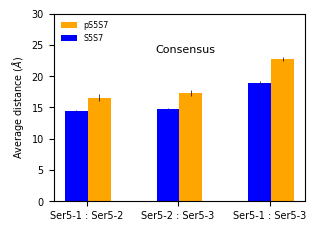

In [39]:
plt.figure()

x = ["Ser5-1 : Ser5-2","Ser5-2 : Ser5-3","Ser5-1 : Ser5-3"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_overall.loc['mean'], 0.25, yerr = phos_ser_dist_overall.loc['sem'], error_kw={'elinewidth': 0.5}, label='pS5S7', color='orange')
plt.bar(x_axis - 0.11, ser_dist_overall.loc['mean'], 0.25, yerr = ser_dist_overall.loc['sem'], error_kw={'elinewidth': 0.5}, label='S5S7', color='blue')
plt.xticks(x_axis, x, fontsize = 7)
plt.yticks(fontsize = 7)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("Average distance ($\AA$)", fontsize = 7)
plt.ylim(top=30)  
plt.ylim(bottom=0)
#plt.title("Overall")
plt.text(0.75, 25, 'Consensus', fontsize=8, verticalalignment='top')

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('ser5_distances_con.png', dpi=300, bbox_inches='tight')

plt.show()

Text(0.5, 1.0, 'Pro6 in Turn')

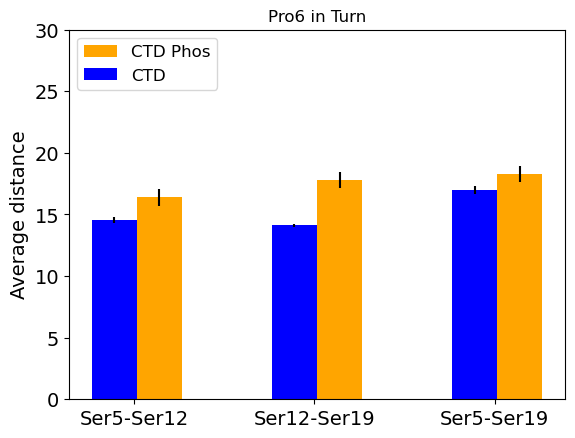

In [51]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_pro6_turn.loc['mean'], 0.25, yerr = phos_ser_dist_pro6_turn.loc['sem'], label='CTD Phos', color='orange')
plt.bar(x_axis - 0.11, ser_dist_pro6_turn.loc['mean'], 0.25, yerr = ser_dist_pro6_turn.loc['sem'], label='CTD', color='blue')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Pro6 in Turn")

Text(0.5, 1.0, 'Pro3 in Turn')

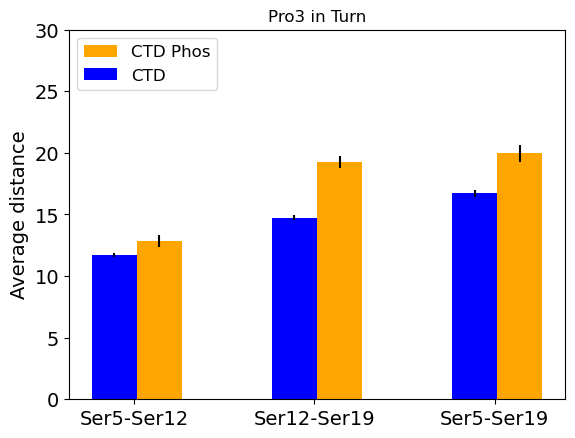

In [52]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_pro3_turn.loc['mean'], 0.25, yerr = phos_ser_dist_pro3_turn.loc['sem'], label='CTD Phos', color='orange')
plt.bar(x_axis - 0.11, ser_dist_pro3_turn.loc['mean'], 0.25, yerr = ser_dist_pro3_turn.loc['sem'], label='CTD', color='blue')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Pro3 in Turn")

# Comparing with no turn

## Pro6 no turn

In [53]:
ser5_dist_sim_list = np.array_split(ser5_dist, nsim)
phos_ser5_dist_sim_list = np.array_split(phos_ser5_dist, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [54]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [55]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = ((sim['Pro:13'] != 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:13'] != 'T')*sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    
    i += 1

In [56]:
# Calculate the SEM (standard error of the mean)
mean_values = ser5_dist_all.mean()
sem_values = ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [57]:
ser_dist_pro6_noturn = ser5_dist_all_final.copy()

In [58]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [59]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = ((sim['Pro:13'] != 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:13'] != 'T')*sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    
    i += 1

In [60]:
# Calculate the SEM (standard error of the mean)
mean_values = phos_ser5_dist_all.mean()
sem_values = phos_ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [61]:
phos_ser_dist_pro6_noturn = phos_ser5_dist_all_final.copy()

## Pro3 no turn

In [62]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [63]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = ((sim['Pro:10'] != 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:10'] != 'T')*sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    
    i += 1

In [64]:
# Calculate the SEM (standard error of the mean)
mean_values = ser5_dist_all.mean()
sem_values = ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [65]:
ser_dist_pro3_noturn = ser5_dist_all_final.copy()

In [66]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [67]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = ((sim['Pro:10'] != 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:10'] != 'T')*sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    
    i += 1

In [68]:
# Calculate the SEM (standard error of the mean)
mean_values = phos_ser5_dist_all.mean()
sem_values = phos_ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [69]:
phos_ser_dist_pro3_noturn = phos_ser5_dist_all_final.copy()

Text(0.5, 1.0, 'Phosphorylated Con')

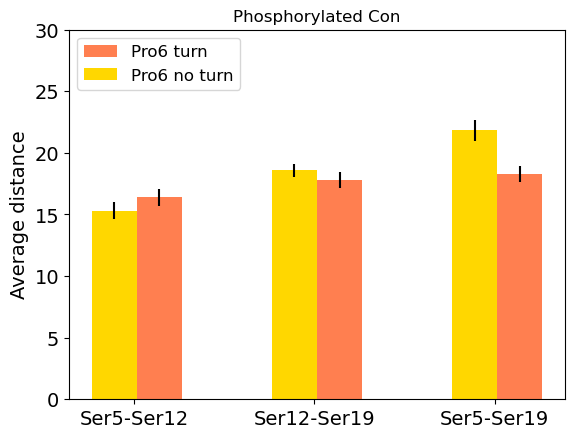

In [70]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_pro6_turn.loc['mean'], 0.25, yerr = phos_ser_dist_pro6_turn.loc['sem'], label='Pro6 turn', color='coral')
plt.bar(x_axis - 0.11, phos_ser_dist_pro6_noturn.loc['mean'], 0.25, yerr = phos_ser_dist_pro6_noturn.loc['sem'], label='Pro6 no turn', color='gold')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Phosphorylated Con")

Text(0.5, 1.0, 'Phosphorylated Con')

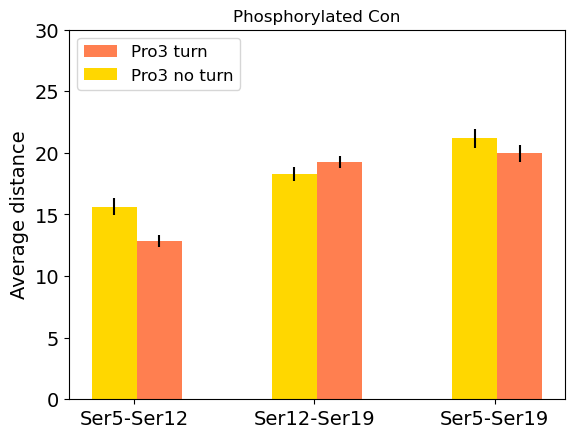

In [71]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_pro3_turn.loc['mean'], 0.25, yerr = phos_ser_dist_pro3_turn.loc['sem'], label='Pro3 turn', color='coral')
plt.bar(x_axis - 0.11, phos_ser_dist_pro3_noturn.loc['mean'], 0.25, yerr = phos_ser_dist_pro3_noturn.loc['sem'], label='Pro3 no turn', color='gold')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Phosphorylated Con")

Text(0.5, 1.0, 'Unphosphorylated Con')

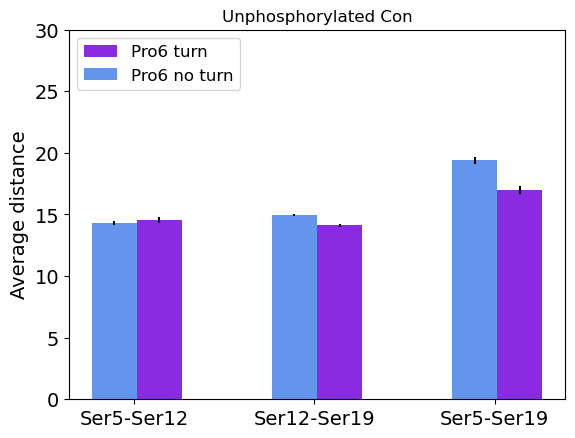

In [72]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, ser_dist_pro6_turn.loc['mean'], 0.25, yerr = ser_dist_pro6_turn.loc['sem'], label='Pro6 turn', color='blueviolet')
plt.bar(x_axis - 0.11, ser_dist_pro6_noturn.loc['mean'], 0.25, yerr = ser_dist_pro6_noturn.loc['sem'], label='Pro6 no turn', color='cornflowerblue')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Unphosphorylated Con")

Text(0.5, 1.0, 'Unphosphorylated Con')

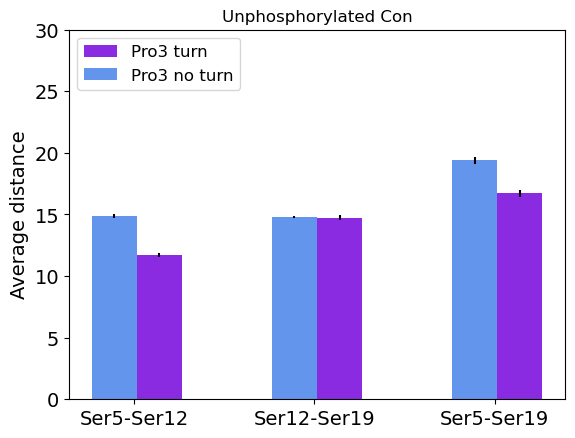

In [73]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, ser_dist_pro3_turn.loc['mean'], 0.25, yerr = ser_dist_pro3_turn.loc['sem'], label='Pro3 turn', color='blueviolet')
plt.bar(x_axis - 0.11, ser_dist_pro3_noturn.loc['mean'], 0.25, yerr = ser_dist_pro3_noturn.loc['sem'], label='Pro3 no turn', color='cornflowerblue')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Unphosphorylated Con")